In [8]:
# Data description

In [53]:
import zarr, numpy as np

import matplotlib.pyplot as plt

f = zarr.open("../recordings/mock48_2500hz_1.5h.zarr", mode="r")
f.info

Name        : 
Type        : Group
Zarr format : 3
Read-only   : True
Store type  : LocalStore

In [10]:
f["current_data"][0, 0:25000]

array([32767, 32767, 32767, ..., 32767, 32767, 32767],
      shape=(25000,), dtype=int16)

In [41]:
pA = f["current_data"][:, ::1000].astype("float32") * f.attrs["current_scale"]

In [42]:
# plt.plot(pA)
pA.shape

(48, 13500)

 ...]

Error in callback <function _draw_all_if_interactive at 0x10e4a2980> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

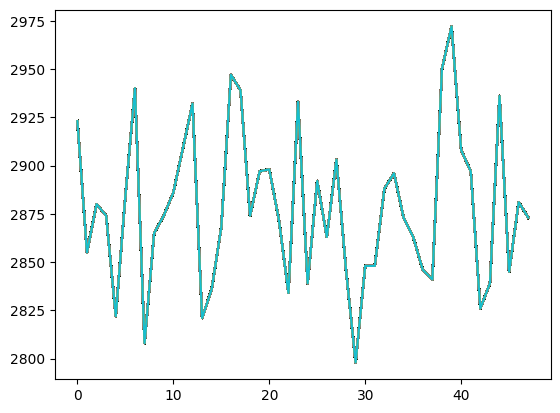

In [43]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

data = pA

# Compute mean and std for each channel
means = np.mean(data, axis=1)
stds = np.std(data, axis=1)
features = np.column_stack((means, stds))

# Cluster channels
n_clusters = 2  # Adjust as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=1).fit(features)
labels = kmeans.labels_

# Sort channels by cluster label
sorted_indices = np.argsort(labels)
sorted_data = data[sorted_indices]

sorted_data.shape


(48, 13500)

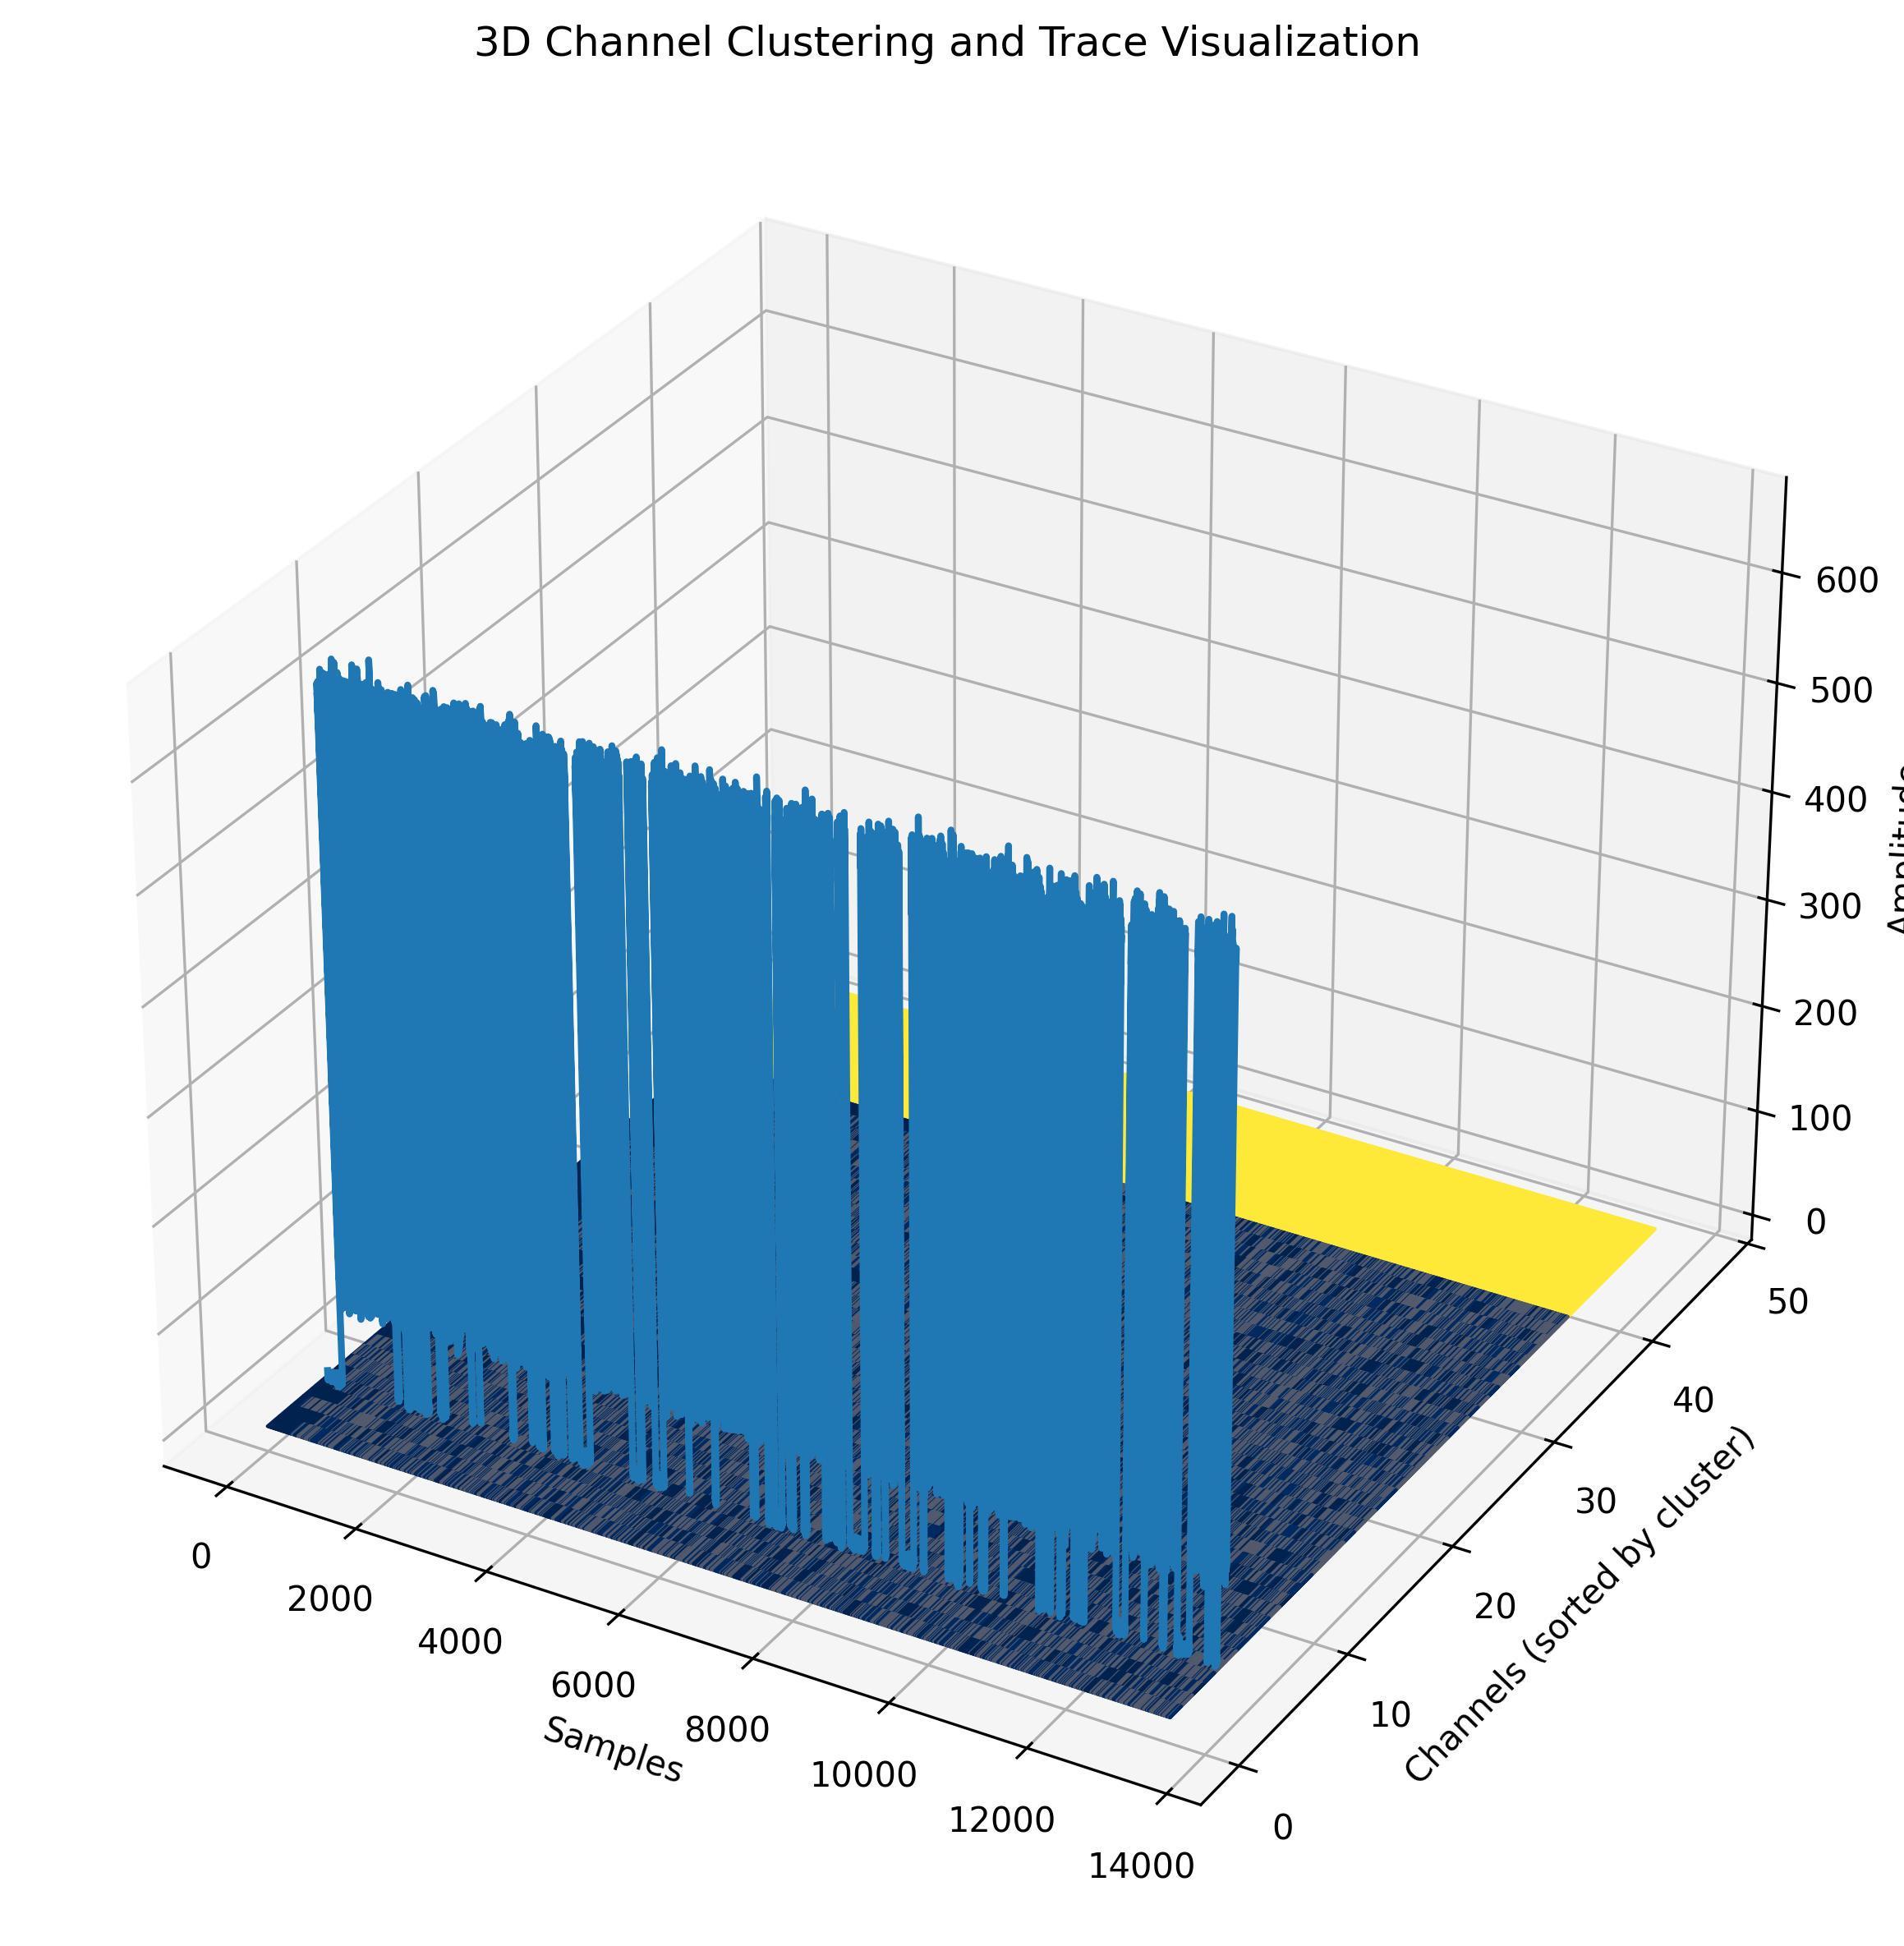

In [44]:
# plt.style.use('ggplot')
# Plot
fig = plt.figure(figsize=(12, 8), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Plot the sorted matrix as an imshow on the horizontal plane
X, Y = np.meshgrid(np.arange(sorted_data.shape[1]), np.arange(sorted_data.shape[0]))
ax.plot_surface(X, Y, np.zeros_like(sorted_data), facecolors=plt.cm.cividis(sorted_data/np.max(sorted_data)), shade=False, zorder=-1, rcount=1000, ccount=1000)

# Plot a selected channel in 3D (e.g., channel 0)
channel_to_plot = 5
ax.plot(np.arange(sorted_data.shape[1]), np.full(sorted_data.shape[1], channel_to_plot), sorted_data[channel_to_plot], linewidth=2, zorder=10)

ax.set_xlabel('Samples')
ax.set_ylabel('Channels (sorted by cluster)')
ax.set_zlabel('Amplitude')
plt.title('3D Channel Clustering and Trace Visualization')
plt.tight_layout()

In [39]:
Y.shape

(48, 135000)